In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import h5py

import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix

import snntorch.functional

import lava.lib.dl.slayer as slayer

from sklearn.model_selection import train_test_split

fs = 128 #Hz

         Only Prophesee DVS demo will not run properly.
         Please install it from https://github.com/prophesee-ai/prophesee-automotive-dataset-toolbox


# Dataset Class that read the Input EEG data
* The input EEG table will includes EEG data and label from the preprocessing stage.
* 23 Subjets, 18 Video (with emotion label), 14 channel in total.
* Sampling rate is 128 Hz, with the segement window to be 3 seconds.

The Dataset pre-processed to fetch all the channels in the same subject, video and segment.

In [3]:
# label transformation
def va_to_4class(v, a):
    if v == 1 and a == 1:
        return 1
    elif v == 1 and a == 0:
        return 2
    elif v == 0 and a == 1:
        return 3
    elif v == 0 and a == 0:
        return 4
    else:
        return 0

In [3]:
class EEGDataset(Dataset):
    def __init__(self, df,n_ch = 14, seg_len = 384):
        self.df = df
        self.n_ch = n_ch
        self.seg_len = seg_len

        # Each sample has its own sub, video, segment
        self.keys = df[["subject","video","segment"]].drop_duplicates().reset_index(drop=True)

    def __len__(self):
        return len(self.keys) # total sample length

    def __getitem__(self, idx):

        key = self.keys.iloc[idx]
        sub = key["subject"]
        vid = key["video"]
        seg = key["segment"]

        # for 1 (subject, video, segment) all 16 channel
        rows = self.df[(self.df["subject"] == sub) &
                       (self.df["video"]   == vid) &
                       (self.df["segment"] == seg)]
        

        # sorted by channel
        rows = rows.sort_values("channel")

        eeg_block = np.zeros((self.n_ch, self.seg_len), dtype=np.float32)

        for i, (_, r) in enumerate(rows.iterrows()): # iternate through all the channel for the same subject,video and segment
            
            if i >= self.n_ch:
                break
            arr = np.asarray(r["EEG_array"], dtype=np.float32)
            eeg_block[i, :] = arr

        eeg = torch.from_numpy(eeg_block)   # [16, 384]
        label = torch.tensor(rows.iloc[0]["label"], dtype=torch.long)

        return eeg, label

## CNN-SNN Network 

In [4]:
def event_rate_loss(x, max_rate=0.01):
    mean_event_rate = torch.mean(torch.abs(x))
    return F.mse_loss(F.relu(mean_event_rate - max_rate), torch.zeros_like(mean_event_rate))

In [4]:
import torch
import torch.nn as nn

class EEG2DCNN(nn.Module):
    def __init__(self, n_classes=4, input_time=384, input_channels=14):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 25, kernel_size=(5, 1)),
            nn.LeakyReLU(0.3, inplace=True),
            nn.Dropout(0.25),

            nn.Conv2d(25, 25, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1)),
            nn.BatchNorm2d(25),
            nn.LeakyReLU(0.3, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(25, 50, kernel_size=(5, 1)),
            nn.LeakyReLU(0.3, inplace=True),
            nn.Dropout(0.25),

            nn.Conv2d(50, 50, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1)),
            nn.BatchNorm2d(50),
            nn.LeakyReLU(0.3, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(50, 100, kernel_size=(5, 1)),
            nn.LeakyReLU(0.3, inplace=True),
            nn.Dropout(0.25),

            nn.Conv2d(100, 100, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1)),
            nn.BatchNorm2d(100),
            nn.LeakyReLU(0.3, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(100, 200, kernel_size=(5, 1)),
            nn.LeakyReLU(0.3, inplace=True),
            nn.Dropout(0.25),

            nn.Conv2d(200, 200, kernel_size=(1, 3), padding=(0, 1)),
            nn.BatchNorm2d(200),
            nn.LeakyReLU(0.3, inplace=True),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_time, input_channels)
            feat = self.features(dummy)
            flat_dim = feat.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 256),
            nn.LeakyReLU(0.3, inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [5]:
seg_eeg = pd.read_csv('/Users/linyuchun/Desktop/Project/SNN/data/EEG_clean_table.csv')

eeg_cols = [c for c in seg_eeg.columns if c.startswith("EEG_clean")]

def extract_valid_eeg(row):
    values = row[eeg_cols].values.astype(float)
    values = values[~np.isnan(values)]  # 移除 NaN
    return values

seg_eeg["EEG_clean"] = seg_eeg.apply(extract_valid_eeg, axis=1)

seg_eeg = seg_eeg.drop(columns=eeg_cols)

In [11]:
CONFIG = {
    "fs": 128,                # Sampling frequency (Hz)
    "decision_window": 3,     # Window duration (seconds)
    "in_channels": 14,        # The simultan
    "out_channels": 50,       # Number of conv filters / hidden units
    "dropout": 0.25,           # Dropout probability
    "batch_size": 8,          # 1 batch = 1 trial (1 subject vs. 1 video)
    "n_classes": 4,
    "lr":  1e-3,
    "num_epochs": 100,
    "save_dir": "./data/checkpoints",
}

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Run one training epoch. Returns total loss."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for data, labels in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        data = data.unsqueeze(1)
        data = data.permute(0,1,3,2)

        spike_rec = model(data)
        # spike_rec = spike_rec.permute(2, 0, 1)  # [23, 66, 4]
        loss = criterion(spike_rec, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        preds = spike_rec.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        avg_loss = total_loss / total if total > 0 else 0.0
        acc = correct / total if total > 0 else 0.0

    return avg_loss, acc



@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Evaluate model on a dataset. Returns (loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for data, labels in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # logits = model(data)
        # probs = torch.softmax(logits, dim=1)
        # pred = logits.argmax(dim=1)
        # print("y[0:8]   :", labels[:8].cpu().tolist())
        # print("logits   :", logits[:4].cpu())
        # print("probs    :", probs[:4].cpu())
        # print("pred[0:8]:", pred[:8].cpu().tolist())

        spike_rec = model(data)
        # spike_rec = spike_rec.permute(2,0,1)
        loss = criterion(spike_rec, labels)
        pred = spike_rec.argmax(dim=1)

        all_preds.append(pred.cpu())
        all_labels.append(labels.cpu())
        
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size

        correct += (pred == labels).sum().item()
        total += batch_size

    avg_loss = total_loss / total if total > 0 else 0.0
    acc = correct / total if total > 0 else 0.0

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    # print(confusion_matrix(all_labels, all_preds))
    return avg_loss, acc


def main(train_losses,valid_losses,train_accs,valid_accs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Load data
    train_dataset, valid_dataset, test_dataset, _ = load_data(seg_eeg)

    # DataLoader
    train_loader = DataLoader(dataset= train_dataset, batch_size=batch, shuffle=True,drop_last=True)
    test_loader = DataLoader(dataset= test_dataset, batch_size=batch, shuffle=True,drop_last=False)
    valid_loader = DataLoader(dataset= valid_dataset, batch_size=batch, shuffle=True,drop_last=False) # can't shuffle or the temporarl dynamic will gone

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

    # Normalized data balance
    all_labels = []
    for _, y_batch in train_loader:
        all_labels.append(y_batch)
    y_all = torch.cat(all_labels)


    counts = torch.bincount(y_all)
    print(counts)
    inv = 1.0 / counts
    class_weights = inv / inv.sum() * len(inv)  # *2 or *3 放大權重差距


    model = EEG2DCNN(n_classes=4, input_time=384, input_channels=14).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])  

    best_valid_acc = 0.0
    for epoch in range(CONFIG["num_epochs"]):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
        # _, train_acc = evaluate(model, train_loader, criterion, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_train_acc = train_acc
            # torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Valid Loss: {valid_loss:.4f}  Acc: {valid_acc:.4f}"
        )

    print(f"\nBest validation accuracy: {best_valid_acc:.4f}")
    print(f"Corresponding train accuracy: {best_train_acc:.4f}")

    # Test with best model
    # model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    _, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test accuracy: {test_acc:.4f}")


if __name__ == "__main__":
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []
    main(train_losses,valid_losses,train_accs,valid_accs)

Device: cpu
=== Group-wise split summary ===
Total segment-samples: 28451
Total trials(groups): 414
Train segments: 17573 | groups: 248
Valid segments: 5204 | groups: 83
Test  segments: 5674 | groups: 83
in_channels: 14
window_size: 384, stride: 384
No trial is split across train/valid/test.
tensor([1092, 2140, 5944, 8360])


RuntimeError: Given groups=1, weight of size [25, 1, 5, 1], expected input[1, 128, 14, 384] to have 1 channels, but got 128 channels instead

In [8]:
# Load data
train_dataset, valid_dataset, test_dataset, _ = load_data(seg_eeg)

batch = 128



for epoch in range(200):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:

        x = x.to(device)  
        y = y.to(device)
        x = x.unsqueeze(1)
        x = x.permute(0,1,3,2)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    print(f"Epoch {epoch+1}: loss={total_loss/total:.4f}, acc={train_acc:.4f}")

=== Group-wise split summary ===
Total segment-samples: 28451
Total trials(groups): 414
Train segments: 17573 | groups: 248
Valid segments: 5204 | groups: 83
Test  segments: 5674 | groups: 83
in_channels: 14
window_size: 384, stride: 384
No trial is split across train/valid/test.
Epoch 1: loss=1.4068, acc=0.4376
Epoch 2: loss=1.2161, acc=0.4579


KeyboardInterrupt: 

In [ ]:
class CNNBench(nn.Module):
    """Hybrid CNN-SNN for binary classification of multi-channel time-series data.

    Args:
        fs: Sampling frequency (Hz).
        decision_window: Duration of each input window (seconds).
        in_channels: Number of input channels (e.g., EEG electrodes).
        out_channels: Number of convolutional filters / hidden units.
        n_classes: Number of final predicted classes.
        dropout: Dropout probability applied after batch norm. Default: 0.5.
    """
    def __init__(self, fs, decision_window, in_channels, out_channels, n_classes, dropout=0.5):
        super().__init__() # 14 channel, segmetation window = 3s (128Hz)

        self.fs = fs
        self.decision_window = decision_window
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.n_classes = n_classes

        # Derived params
        self.window_samples = fs * decision_window
        self.kernel_time = fs // 4   # 32
        self.stride_time = fs // 8   # 16
        self.time_steps = (self.window_samples - self.kernel_time) // self.stride_time + 1


        self.cnn = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=out_channels // 2,
                kernel_size=(1, self.kernel_time),    # (channel=1, time=K)
                stride=(1, self.stride_time),
                padding=(0, self.kernel_time // 2+self.stride_time//2),
            ),
            nn.BatchNorm2d(out_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

         # spatial branch: 只沿 channel 捲，time kernel=1
        self.spat_branch = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=out_channels // 2,
                kernel_size=(in_channels, self.kernel_time//2),    # 一次看所有 channel
                stride=(1, self.stride_time),
                padding=(0, self.kernel_time // 2),
            ),
            nn.BatchNorm2d(out_channels // 2),
            nn.Dropout(dropout),
        )

        # fuse + pool
        self.fuse = nn.Sequential(
            nn.Conv2d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel_size=(1, 1),
            ),
            nn.BatchNorm2d(out_channels),
            nn.AdaptiveAvgPool2d((1, 1)),
        )


        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(out_channels, out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_channels, self.n_classes)
        )

    def forward(self, x):
        # x: (B, C, T)
        x = x.unsqueeze(1)               # (B, 1, C, T)

        z_t = self.cnn(x)        # (B, F/2, C, T')
        z_s = self.spat_branch(x)        # (B, F/2, 1, T)

        print(z_t.shape)
        print(z_s.shape)
        # 對齊 channel 維度（spatial branch 只有 1，高度 broadcast）
        if z_s.size(2) == 1 and z_t.size(2) > 1:
            z_s = z_s.expand(-1, -1, z_t.size(2), -1)  # (B, F/2, C, T)

        z = torch.cat([z_t, z_s], dim=1) # (B, F, C, T')
        z = self.fuse(z)                 # (B, F, 1, 1)
        z = self.fc(z)       
        # out = self.cnn(x)              # (B, C, 1)
        # out = out.squeeze(-1)          # (B, C)
        # out = self.fc(out)             # (B, num_classes)

        # out = out.unsqueeze(2) 
        return z
    

        

In [ ]:
class SNNEMotionNet(nn.Module):
    """Hybrid CNN-SNN for binary classification of multi-channel time-series data.

    Args:
        fs: Sampling frequency (Hz).
        decision_window: Duration of each input window (seconds).
        in_channels: Number of input channels (e.g., EEG electrodes).
        out_channels: Number of convolutional filters / hidden units.
        n_classes: Number of final predicted classes.
        dropout: Dropout probability applied after batch norm. Default: 0.5.
    """
    def __init__(self, fs, decision_window, in_channels, out_channels, n_classes, dropout=0.5):
        super().__init__() # 14 channel, segmetation window = 3s (128Hz)

        self.fs = fs
        self.decision_window = decision_window
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.n_classes = n_classes

        # Derived params
        self.window_samples = fs * decision_window
        self.kernel_time = fs // 4   # 64
        self.stride_time = fs // 8   # 32
        self.time_steps = (self.window_samples - self.kernel_time) // self.stride_time + 1

        # Neurons param
        encoder_params = {
                "threshold": 0.3,          # U_thr = 1 V from paper
                "current_decay": 0.9,      # Current time step 留下 90%
                "voltage_decay": 0.9,      # Voltage time step 留下 90%
                "tau_grad": 1.0,           # surrogate gradient time const
                "scale_grad": 1.0,         # gradient value, default 1
                "scale": 1 << 6,           # default initial setting
                "norm": None,
                "dropout": None,
                "shared_param": True,      # 先全 channel 共用一組參數
                "persistent_state": False, # 每個 batch 從 0 開始積分，符合論文 batch 訓練
                "requires_grad": True,    # encoder 參數先不學
                "graded_spike": False,     # 輸出 0/1 spike，不要連續值
            }
        dense_params = {
                'threshold'     : 0.1,
                'current_decay' : 1,    # default setting from tutorial, no decay 
                'voltage_decay' : 0.1,  # default setting, keep only 0.1 
                'requires_grad' : True, # learn from back-prop    
            }


        self.cnn = nn.Sequential(
            nn.Conv1d(
                in_channels = in_channels, 
                out_channels = out_channels,
                kernel_size = self.kernel_time,
                stride=self.stride_time, # moving step
            ),
            nn.BatchNorm1d(out_channels),

            nn.Conv1d(out_channels, out_channels,
              kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.Dropout(dropout), # prevent overfitting
        )

        self.endcoder = nn.ModuleList([
            slayer.block.cuba.Input(encoder_params),  # delta encoding of the input
        ])
        self.snn = nn.ModuleList([
            slayer.block.cuba.Dense(dense_params, out_channels, out_channels),
            slayer.block.cuba.Dense(dense_params, out_channels, self.n_classes),
        ])

        # data visulization param init
        self.spike_mon_enc = None   # 用來暫存 spike
        self.spike_mon_snn1 = None  
        self.spike_mon_snn2 = None   



    def forward(self, x):
        # print("Original Shape: ", x.shape)
        z = self.cnn(x) #  run CNN
        # print("After CNN:",z.shape)
        for block in self.endcoder: # pass into SNN blocks
            z = block(z)
        
        self.spike_mon_enc = z.detach().cpu()  # 存下來，shape [B, 50, 1, T]
        # print("After Encoder:",z.shape)
        # print("After modify", z.shape)

        # --------- For output Checking ----------
        # z = self.snn[0](z)
        # self.spike_mon_snn1 = z.detach().cpu()
        # z = self.snn[1](z)
        # self.spike_mon_snn2 = z.detach().cpu()
        # ---------------end of checking ------
        
        for block in self.snn: # pass into SNN blocks
            z = block(z)
        # print("Final output shape: ", z.shape)
        # z = z.squeeze(0).squeeze(2)   # [B, C, T] 
        return z
    

        

In [10]:
seg_eeg = pd.read_csv('/Users/linyuchun/Desktop/Project/SNN/data/EEG_clean_table.csv')

eeg_cols = [c for c in seg_eeg.columns if c.startswith("EEG_clean")]

def extract_valid_eeg(row):
    values = row[eeg_cols].values.astype(float)
    values = values[~np.isnan(values)]  # 移除 NaN
    return values

seg_eeg["EEG_clean"] = seg_eeg.apply(extract_valid_eeg, axis=1)

seg_eeg = seg_eeg.drop(columns=eeg_cols)

# Model Traininig Phase

In [ ]:
# Traini parameter
batch  = 20  # batch size (all segments in 1 trial)
input_ch = 66
lr     = 0.001 # learning rate
lam    = 0.01  # lagrangian for event rate loss
epochs = 100  # training epochs
steps  = [60, 120, 160] # learning rate reduction milestones

# set the device to CPU, if has CUDA use CUDA
device = torch.device('cpu')

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
train_dataset, valid_dataset, test_dataset, _ = load_data(seg_eeg)

NameError: name 'load_data' is not defined

In [ ]:
# DataLoader
train_loader = DataLoader(dataset= train_dataset, batch_size=batch, shuffle=True,drop_last=True)
test_loader = DataLoader(dataset= test_dataset, batch_size=batch, shuffle=True,drop_last=False)
valid_loader = DataLoader(dataset= valid_dataset, batch_size=batch, shuffle=True,drop_last=False) # can't shuffle or the temporarl dynamic will gone


model = CNNBench(
    fs=CONFIG["fs"],
    decision_window=CONFIG["decision_window"],
    in_channels=CONFIG["in_channels"],
    out_channels=CONFIG["out_channels"],
    n_classes=CONFIG["n_classes"],
    dropout=CONFIG["dropout"]
).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

In [ ]:
train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
_, train_acc = evaluate(model, train_loader, criterion, device)

torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
torch.Size([66, 20, 1, 26])
torch.Size([66, 20, 14, 26])
to

In [7]:
"""
Training script for the CNN-SNN model.

Adapt the `load_data()` function to your dataset. The rest of the pipeline
(training loop, validation, early saving, testing) is general-purpose.

Requirements:
    torch, snntorch, numpy, scikit-learn
"""

import torch
from torch.utils.data import DataLoader, TensorDataset
import snntorch.functional
import numpy as np
from pathlib import Path

from ref_cnn_snn_model import CnnSnn


# =============================================================================
# Configuration
# =============================================================================

CONFIG = {
    "fs": 128,                # Sampling frequency (Hz)
    "decision_window": 3,     # Window duration (seconds)
    "in_channels": 14,        # The simultan
    "out_channels": 50,       # Number of conv filters / hidden units
    "dropout": 0.25,           # Dropout probability
    "batch_size": 8,          # 1 batch = 1 trial (1 subject vs. 1 video)
    "n_classes": 4,
    "lr":  1e-3,
    "num_epochs": 1000,
    "save_dir": "./data/checkpoints",
}


# =============================================================================
# Data loading — MODIFY THIS FOR YOUR DATASET
# =============================================================================

def load_data(
    df,
    train_ratio=0.6,
    valid_ratio=0.2,
    test_ratio=0.2,
    random_state=42,
    num_channels=14,
    window_size=384,     # e.g. 3 sec if fs=128
    stride=384,          # non-overlap; set 192 for 50% overlap
    drop_last=True,      # whether to drop the last incomplete window
):
    """
    Input df:
        one row = one channel of one full EEG trial

    Expected columns:
        - subject
        - video
        - channel
        - EEG_array   : full 1D EEG signal of that channel, shape (T_full,)
        - label

    Pipeline:
        1. segment each full trial signal into windows
        2. stack 14 channels into 2D EEG_array of shape (C, T_window)
        3. split by (subject, video), so all segments from one trial stay together

    Returns:
        train_dataset, valid_dataset, test_dataset, in_channels
    """

    # -----------------------------
    # 0) basic checks
    # -----------------------------
    required_cols = {"subject", "video", "channel", "EEG_clean", "label"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if not np.isclose(train_ratio + valid_ratio + test_ratio, 1.0):
        raise ValueError("train_ratio + valid_ratio + test_ratio must equal 1.0")

    df = df.copy()
    df = df.sort_values(["subject", "video", "channel"]).reset_index(drop=True)

    # -----------------------------
    # 1) segment full EEG trial first
    #    output rows: subject, video, channel, segment, EEG_segment, label
    # -----------------------------
    segmented_rows = []

    trial_group_cols = ["subject", "video", "channel"]
    grouped_trial_channel = df.groupby(trial_group_cols)

    for (sub, vid, ch), g in grouped_trial_channel:
        if len(g) != 1:
            raise ValueError(
                f"(subject={sub}, video={vid}, channel={ch}) has {len(g)} rows. "
                "Expected exactly 1 row per full-trial channel."
            )

        full_signal = np.asarray(g.iloc[0]["EEG_clean"], dtype=np.float32)
        label = int(g.iloc[0]["label"])

        if full_signal.ndim != 1:
            raise ValueError(
                f"(subject={sub}, video={vid}, channel={ch}) full EEG must be 1D, "
                f"got shape {full_signal.shape}"
            )

        T_full = len(full_signal)

        # if the total length is smaller then 1 window
        if T_full < window_size:
            # remove incomplete window, length alignment
            if drop_last:
                continue
            
            # add the padding to fill up the incomplete window
            else:
                padded = np.zeros(window_size, dtype=np.float32)
                padded[:T_full] = full_signal
                segmented_rows.append({
                    "subject": sub,
                    "video": vid,
                    "channel": ch,
                    "segment": 0,
                    "EEG_segment": padded,
                    "label": label,
                })
                continue

        seg_idx = 0
        for start in range(0, T_full, stride):
            end = start + window_size
            # Normal segment process
            if end <= T_full:
                seg = full_signal[start:end]

            # edge case
            else:
                # remove any incomplete window, length alignment
                if drop_last:
                    break
                seg = np.zeros(window_size, dtype=np.float32)
                valid_len = T_full - start
                if valid_len <= 0:
                    break
                seg[:valid_len] = full_signal[start:T_full]

            segmented_rows.append({
                "subject": sub,
                "video": vid,
                "channel": ch,
                "segment": seg_idx,
                "EEG_segment": seg,
                "label": label,
            })
            seg_idx += 1

    df_segch = pd.DataFrame(segmented_rows)

    if len(df_segch) == 0:
        raise ValueError("No segmented data generated. Check window_size/stride/drop_last.")

    # -----------------------------
    # 2) stack 14 channels -> 2D (C, T)
    #    one row becomes one (subject, video, segment)
    # -----------------------------
    df_segch = df_segch.sort_values(
        ["subject", "video", "segment", "channel"]
    ).reset_index(drop=True)

    group_cols = ["subject", "video", "segment"]
    grouped = df_segch.groupby(group_cols)

    rows = []
    for (sub, vid, seg), g in grouped:
        if len(g) != num_channels:
            raise ValueError(
                f"(subject={sub}, video={vid}, segment={seg}) "
                f"has {len(g)} channels, expected {num_channels}"
            )

        signals = []
        for _, row in g.iterrows():
            sig = np.asarray(row["EEG_segment"], dtype=np.float32)
            if sig.ndim != 1:
                raise ValueError(
                    f"(subject={sub}, video={vid}, segment={seg}) "
                    f"segment must be 1D, got shape {sig.shape}"
                )
            signals.append(sig)

        lengths = {len(s) for s in signals}
        if len(lengths) != 1:
            raise ValueError(
                f"(subject={sub}, video={vid}, segment={seg}) "
                f"channel segment lengths mismatch: {lengths}"
            )

        eeg_2d = np.stack(signals, axis=0)   # (C, T_window)
        label = int(g["label"].iloc[0])

        rows.append({
            "subject": sub,
            "video": vid,
            "segment": seg,
            "EEG_array": eeg_2d,
            "label": label,
        })

    df = pd.DataFrame(rows)

    # -----------------------------
    # 3) build group id = one full trial
    # -----------------------------
    df["group_id"] = df["subject"].astype(str) + "__" + df["video"].astype(str)
    unique_groups = df["group_id"].unique()

    # -----------------------------
    # 4) split by group, not by row
    # -----------------------------
    train_groups, temp_groups = train_test_split(
        unique_groups,
        test_size=(1.0 - train_ratio),
        random_state=random_state,
        shuffle=True,
    )

    valid_portion_of_temp = valid_ratio / (valid_ratio + test_ratio)

    valid_groups, test_groups = train_test_split(
        temp_groups,
        test_size=(1.0 - valid_portion_of_temp),
        random_state=random_state,
        shuffle=True,
    )

    train_df = df[df["group_id"].isin(train_groups)].copy()
    valid_df = df[df["group_id"].isin(valid_groups)].copy()
    test_df  = df[df["group_id"].isin(test_groups)].copy()

    # -----------------------------
    # 5) Convert table -> tensors
    # -----------------------------
    def df_to_dataset(split_df):
        if len(split_df) == 0:
            raise ValueError("One split is empty. Adjust split ratios or dataset size.")

        x_list = []
        y_list = []

        for _, row in split_df.iterrows():
            x = np.asarray(row["EEG_array"], dtype=np.float32)   # (C, T_window)

            if x.ndim != 2:
                raise ValueError(
                    f"Each EEG_array must have shape (C, T), got shape {x.shape}"
                )

            x_list.append(x)
            y_list.append(int(row["label"]))

        x = np.stack(x_list, axis=0)   # (N, C, T)
        y = np.asarray(y_list, dtype=np.int64)

        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.from_numpy(y).long()
        return TensorDataset(x_tensor, y_tensor)

    train_dataset = df_to_dataset(train_df)
    valid_dataset = df_to_dataset(valid_df)
    test_dataset  = df_to_dataset(test_df)

    # -----------------------------
    # 6) infer input channels
    # -----------------------------
    sample_x = np.asarray(df.iloc[0]["EEG_array"], dtype=np.float32)
    in_channels = sample_x.shape[0]

    # -----------------------------
    # 7) logging
    # -----------------------------
    print("=== Group-wise split summary ===")
    print(f"Total segment-samples: {len(df)}")
    print(f"Total trials(groups): {len(unique_groups)}")
    print(f"Train segments: {len(train_df)} | groups: {len(train_groups)}")
    print(f"Valid segments: {len(valid_df)} | groups: {len(valid_groups)}")
    print(f"Test  segments: {len(test_df)} | groups: {len(test_groups)}")
    print(f"in_channels: {in_channels}")
    print(f"window_size: {window_size}, stride: {stride}")
    print("No trial is split across train/valid/test.")

    return train_dataset, valid_dataset, test_dataset, in_channels


# =============================================================================
# Training & evaluation
# =============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Run one training epoch. Returns total loss."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for data, labels in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)
        

        spike_rec = model(data)
        # spike_rec = spike_rec.permute(2, 0, 1)  # [23, 66, 4]
        loss = criterion(spike_rec, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        preds = spike_rec.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        avg_loss = total_loss / total if total > 0 else 0.0
        acc = correct / total if total > 0 else 0.0

    return avg_loss, acc





@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Evaluate model on a dataset. Returns (loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for data, labels in dataloader:
        data = data.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # logits = model(data)
        # probs = torch.softmax(logits, dim=1)
        # pred = logits.argmax(dim=1)
        # print("y[0:8]   :", labels[:8].cpu().tolist())
        # print("logits   :", logits[:4].cpu())
        # print("probs    :", probs[:4].cpu())
        # print("pred[0:8]:", pred[:8].cpu().tolist())

        spike_rec = model(data)
        # spike_rec = spike_rec.permute(2,0,1)
        loss = criterion(spike_rec, labels)
        pred = spike_rec.argmax(dim=1)

        all_preds.append(pred.cpu())
        all_labels.append(labels.cpu())
        
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size

        correct += (pred == labels).sum().item()
        total += batch_size

    avg_loss = total_loss / total if total > 0 else 0.0
    acc = correct / total if total > 0 else 0.0

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    # print(confusion_matrix(all_labels, all_preds))
    return avg_loss, acc


def main(train_losses,valid_losses,train_accs,valid_accs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Load data
    train_dataset, valid_dataset, test_dataset, _ = load_data(seg_eeg)

    # DataLoader
    train_loader = DataLoader(dataset= train_dataset, batch_size=batch, shuffle=True,drop_last=True)
    test_loader = DataLoader(dataset= test_dataset, batch_size=batch, shuffle=True,drop_last=False)
    valid_loader = DataLoader(dataset= valid_dataset, batch_size=batch, shuffle=True,drop_last=False) # can't shuffle or the temporarl dynamic will gone

    # Initialize model
    # model = SNNEMotionNet(
    #     fs=CONFIG["fs"],
    #     decision_window=CONFIG["decision_window"],
    #     in_channels=CONFIG["in_channels"],
    #     out_channels=CONFIG["out_channels"],
    #     n_classes=CONFIG["n_classes"],
    #     dropout=CONFIG["dropout"]
    # ).to(device)
    model = CNNBench(
        fs=CONFIG["fs"],
        decision_window=CONFIG["decision_window"],
        in_channels=CONFIG["in_channels"],
        out_channels=CONFIG["out_channels"],
        n_classes=CONFIG["n_classes"],
        dropout=CONFIG["dropout"]
    ).to(device)

    # Normalized data balance
    all_labels = []
    for _, y_batch in train_loader:
        all_labels.append(y_batch)
    y_all = torch.cat(all_labels)

    counts = torch.bincount(y_all)
    inv = 1.0 / counts
    class_weights = inv / inv.sum() * len(inv) * 2.0  # *2 or *3 放大權重差距


    # criterion = snntorch.functional.loss.ce_rate_loss()
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

    # Training loop with best-model checkpointing
    save_dir = Path(CONFIG["save_dir"])
    save_dir.mkdir(parents=True, exist_ok=True)
    # checkpoint_path = save_dir / "best_model.pt"

    best_valid_acc = 0.0
    for epoch in range(CONFIG["num_epochs"]):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
        # _, train_acc = evaluate(model, train_loader, criterion, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_train_acc = train_acc
            # torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Valid Loss: {valid_loss:.4f}  Acc: {valid_acc:.4f}"
        )

    print(f"\nBest validation accuracy: {best_valid_acc:.4f}")
    print(f"Corresponding train accuracy: {best_train_acc:.4f}")

    # Test with best model
    # model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    _, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test accuracy: {test_acc:.4f}")


if __name__ == "__main__":
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []
    main(train_losses,valid_losses,train_accs,valid_accs)

Device: cpu


KeyboardInterrupt: 

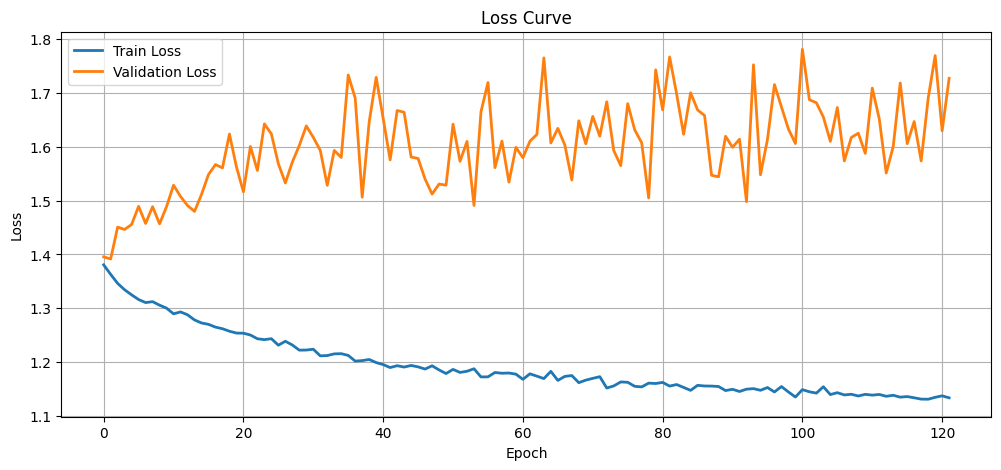

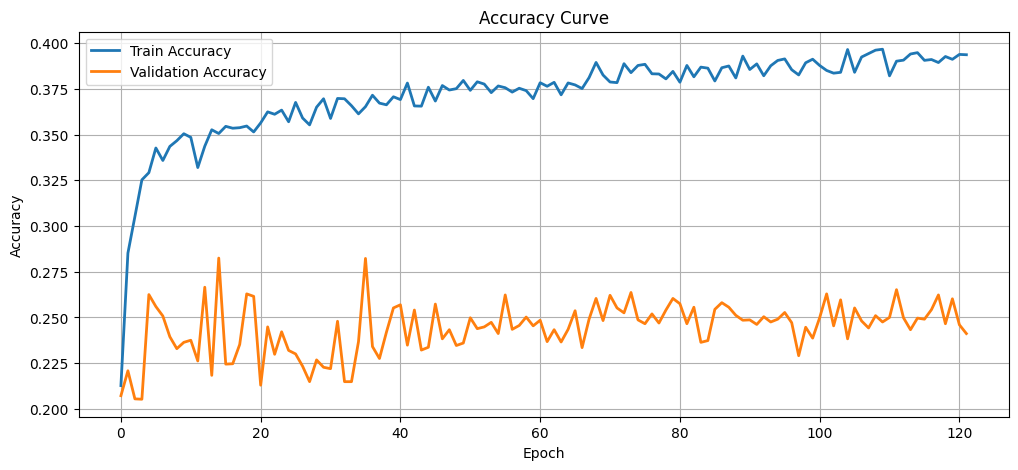

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(valid_losses, label='Validation Loss', linewidth=2)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12,5))

plt.plot(train_accs, label='Train Accuracy', linewidth=2)
plt.plot(valid_accs, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [ ]:
CONFIG = {
    "fs": 128,                # Sampling frequency (Hz)
    "decision_window": 3,     # Window duration (seconds)
    "in_channels": 14,        # The simultan
    "out_channels": 50,       # Number of conv filters / hidden units
    "dropout": 0.5,           # Dropout probability
    "batch_size": 8,          # 1 batch = 1 trial (1 subject vs. 1 video)
    "n_classes": 4,
    "lr": 1e-3,
    "num_epochs": 1000,
    "save_dir": "./data/checkpoints",
}


net = SNNEMotionNet(
    fs=CONFIG["fs"],
    decision_window=CONFIG["decision_window"],
    in_channels=CONFIG["in_channels"],
    out_channels=CONFIG["out_channels"],
    n_classes=CONFIG["n_classes"],
    dropout=CONFIG["dropout"]
).to(device)

optimizer = torch.optim.RAdam(net.parameters(), lr=CONFIG['lr'])

# Dataset
# Train_test_split (60% training, 20% testing, 20% testing)
train_df, test_df = train_test_split(
    seg_eeg,
    test_size=0.4,
    random_state=42,
    shuffle=False
)

valid_df, test_df = train_test_split(
    seg_eeg,
    test_size=0.5,
    random_state=42,
    shuffle=False
)
# DataLoader
train_loader = DataLoader(dataset= EEGDataset(train_df), batch_size=batch, shuffle=False,drop_last=True)
test_loader = DataLoader(dataset= EEGDataset(test_df), batch_size=batch, shuffle=False,drop_last=True)
valid_loader = DataLoader(dataset= EEGDataset(test_df), batch_size=batch, shuffle=False,drop_last=True) # can't shuffle or the temporarl dynamic will gone

stats = slayer.utils.LearningStats()

error = snntorch.functional.loss.ce_rate_loss()

assistant = slayer.utils.Assistant(
    net=net,
    error=error,
    optimizer=optimizer,
    stats=stats,
    classifier=slayer.classifier.Rate.predict
)

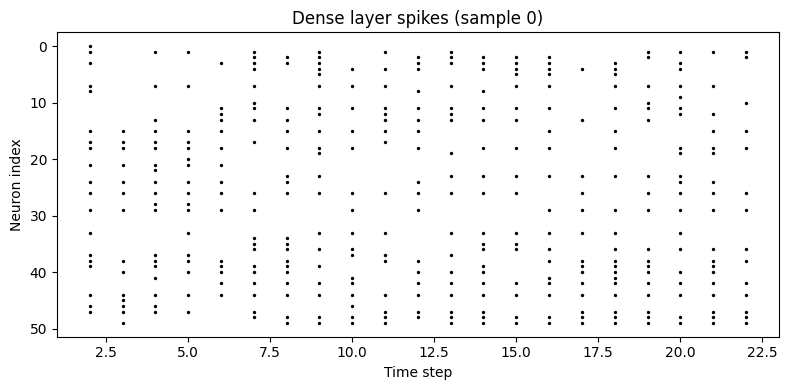

In [ ]:
import matplotlib.pyplot as plt

spk = net.spike_mon_enc    # [B, C, H, T] = [batch, neurons, 1, time]
snn1 = net.spike_mon_snn1  # [B, C, H, W, T] = [batch, neurons, 1, 1, time]
snn2 = net.spike_mon_snn2

# the spike output of snn 1st layer
spk = snn1[0]             # [C, 1, 1, T] for SNN output
spk = spk.squeeze(1).squeeze(1)      # [C, T]

# spk 是 0/1，轉成 (t, neuron) 的座標
neuron_idx, time_idx = spk.nonzero(as_tuple=True)

plt.figure(figsize=(8,4))
plt.scatter(time_idx, neuron_idx, s=2, c='k')
plt.xlabel('Time step')
plt.ylabel('Neuron index')
plt.title('Dense layer spikes (sample 0)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
trained_folder = 'Trained'
os.makedirs(trained_folder, exist_ok=True)

logs_folder = 'Trained'
os.makedirs(logs_folder, exist_ok=True)


for epoch in range(epochs):
    if epoch in steps:
        for param_group in optimizer.param_groups:    
            print('\nLearning rate reduction from', param_group['lr'])
            param_group['lr'] /= 10/3
        
    for i, (input, ground_truth) in enumerate(train_loader): # training loop
        assistant.train(input, ground_truth)
        print(f'\r[Epoch {epoch:3d}/{epochs}] {stats}', end='')
    
    for i, (input, ground_truth) in enumerate(test_loader): # testing loop
        assistant.test(input, ground_truth)
        print(f'\r[Epoch {epoch:3d}/{epochs}] {stats}', end='')
        
    if epoch%50==49: print() 
    # if stats.testing.best_loss:  
    #     torch.save(net.state_dict(), trained_folder + '/network.pt')
    stats.update()
    stats.save(trained_folder + '/')
    
    # gradient flow monitoring
    # net.grad_flow(trained_folder + '/')
    
    # checkpoint saves
    if epoch%10 == 0:
        torch.save({'net': net.state_dict(), 'optimizer': optimizer.state_dict()}, logs_folder + f'/checkpoint{epoch}.pt')    

[Epoch   0/100] Train loss =     5.83302                          accuracy = 0.01515 

RuntimeError: Class values must be smaller than num_classes.